In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F 

from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix


In [5]:
# MNIST IMAGE -> TENSOR

transform = transforms.ToTensor()

In [8]:
train_data = datasets.MNIST(root='../pytorch-for-deep-learning/Data', train=True, download=True, transform=transform)

In [7]:
test_data = datasets.MNIST(root='../pytorch-for-deep-learning/Data', train=False, download=True, transform=transform)

In [12]:
print(type(train_data))
type(train_data[0])

<class 'torchvision.datasets.mnist.MNIST'>


tuple

In [13]:
image, label = train_data[0]
print(image.shape)
label


torch.Size([1, 28, 28])


5

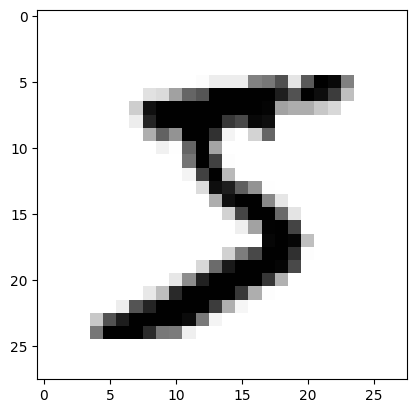

In [15]:
plt.imshow(image[0], cmap='gist_yarg')

In [16]:
torch.manual_seed(101)

train_loader = DataLoader(train_data, batch_size=100, shuffle=True)
test_loader = DataLoader(test_data, batch_size=500, shuffle=False)
  

In [17]:
from torchvision.utils import make_grid 
np.set_printoptions(formatter=dict(int=lambda x: f'{x:4}')) # Formatting

<Token var=<ContextVar name='format_options' default={'edgeitems': 3, 'threshold': 1000, 'floatmode': 'maxprec', 'precision': 8, 'suppress': False, 'linewidth': 75, 'nanstr': 'nan', 'infstr': 'inf', 'sign': '-', 'formatter': None, 'legacy': 9223372036854775807, 'override_repr': None} at 0x770061dcc130> at 0x76ff16b85680>

In [18]:
# Grab the first batch of images
for images,labels in train_loader: 
    break

# Print the first 12 labels
print('Labels: ', labels[:12].numpy())

Labels:  [   7    2    3    5    8    5    3    6    9    9    1    3]


In [20]:
images.shape # 100 images, each image is 28x28 pixels

torch.Size([100, 1, 28, 28])

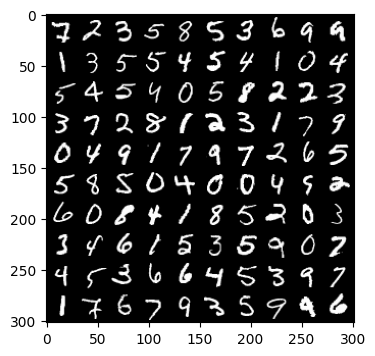

In [21]:
im = make_grid(images, nrow=10)  # the default nrow is 8
# print the first 12 images
plt.figure(figsize=(12,4))
# We need to transpose the images from CWH to WHC
plt.imshow(np.transpose(im.numpy(), (1, 2, 0)))

In [22]:
class MultiLayerPeceptron(nn.Module):
    def __init__(self, in_sz=784, out_sz=10, layers=[120,84]):
        super().__init__()
        self.fc1 = nn.Linear(in_sz, layers[0])
        self.fc2 = nn.Linear(layers[0], layers[1])
        self.fc3 = nn.Linear(layers[1], out_sz)
        
    def forward(self, X):
        X = F.relu(self.fc1(X))
        X = F.relu(self.fc2(X))
        X = self.fc3(X)
        return F.log_softmax(X, dim=1)

torch.manual_seed(101)
model = MultiLayerPeceptron()
model

MultiLayerPeceptron(
  (fc1): Linear(in_features=784, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [23]:
 # ANN ---> CNN
for param in model.parameters():
    print(param.numel())

94080
120
10080
84
840
10


In [24]:
critertion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [27]:
images.shape # ----> convert to [100, 784]

torch.Size([100, 1, 28, 28])

In [28]:
images.view(100, -1).shape

torch.Size([100, 784])